In [1]:
import pathlib
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, callbacks

# ── Constants ────────────────────────────────────────────────
RANDOM_SEED  = 42
SEQUENCE_LEN = 60
NUM_FEATURES = 126
BATCH_SIZE   = 32
EPOCHS       = 150      # EarlyStopping will halt before this
LR           = 5e-4

DATA_DIR  = pathlib.Path("../data/hand_v2")
MODEL_DIR = pathlib.Path("../saved_models/v2")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs       : {gpus if gpus else 'none — running on CPU'}")

TensorFlow : 2.21.0
Keras      : 3.14.1
GPUs       : none — running on CPU


In [2]:
# Load augmented training set and original val/test sets
X_train = np.load(DATA_DIR / "X_train_aug.npy")
y_train = np.load(DATA_DIR / "y_train_aug.npy")

X_val   = np.load(DATA_DIR / "X_val_hand.npy")
y_val   = np.load(DATA_DIR / "y_val_hand.npy")

X_test  = np.load(DATA_DIR / "X_test_hand.npy")
y_test  = np.load(DATA_DIR / "y_test_hand.npy")

NUM_CLASSES = y_train.shape[1]

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Classes : {NUM_CLASSES}")

X_train : (10680, 60, 126)   y_train : (10680, 204)
X_val   : (232, 60, 126)     y_val   : (232, 204)
X_test  : (465, 60, 126)    y_test  : (465, 204)
Classes : 204


In [3]:
def build_bigru_attention(sequence_len, num_features, num_classes):
    """
    BiGRU + Multi-Head Self-Attention with residual connection.

    Architecture:
      Input (60, 126)
      → BiGRU(128, return_sequences=True) + BatchNorm + Dropout(0.3)
      → BiGRU(64,  return_sequences=True) + BatchNorm
      → MultiHeadAttention(4 heads, key_dim=32)
      → Add (residual) + LayerNorm
      → GlobalAveragePooling1D
      → Dense(256, relu) + Dropout(0.4)
      → Dense(128, relu) + Dropout(0.3)
      → Dense(num_classes, softmax)
    """
    inp = keras.Input(shape=(sequence_len, num_features), name="input")

    # First BiGRU layer
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=True), name="bigru_1"
    )(inp)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(0.3, name="drop_1")(x)

    # Second BiGRU layer
    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True), name="bigru_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    bigru_out = x   # save for residual

    # Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(
        num_heads=4, key_dim=32, name="mha"
    )(x, x)

    # Residual connection + LayerNorm
    x = layers.Add(name="residual")([bigru_out, attn_out])
    x = layers.LayerNormalization(name="layer_norm")(x)

    # Aggregate over time
    x = layers.GlobalAveragePooling1D(name="gap")(x)

    # Classification head
    x = layers.Dense(256, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.4, name="drop_2")(x)
    x = layers.Dense(128, activation="relu", name="dense_2")(x)
    x = layers.Dropout(0.3, name="drop_3")(x)
    out = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="bigru_attention_v2")
    return model


model = build_bigru_attention(SEQUENCE_LEN, NUM_FEATURES, NUM_CLASSES)
model.summary()

Model: "bigru_attention_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 126)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_1             │ (None, 60, 256)   │    196,608 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 60, 256)   │      1,024 │ bigru_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 60, 256)   │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_2             │ (None, 60, 128)   │    123,648 │ drop_1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 60, 128)   │        512 │ bigru_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 60, 128)   │     66,048 │ bn_2[0][0],       │
│ (MultiHeadAttentio… │                   │            │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 60, 128)   │          0 │ bn_2[0][0],       │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 60, 128)   │        256 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ layer_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 204)       │     26,316 │ drop_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 480,332 (1.83 MB)

 Trainable params: 479,564 (1.83 MB)

 Non-trainable params: 768 (3.00 KB)

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

CHECKPOINT_PATH = MODEL_DIR / "bigru_attn_v2_best.keras"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

print(f"Model checkpoint will be saved to: {CHECKPOINT_PATH}")

Model checkpoint will be saved to: ../saved_models/v2/bigru_attn_v2_best.keras


In [5]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1,
)

elapsed = time.time() - start_time
print(f"\nTraining complete. Time: {elapsed / 60:.1f} minutes")

best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
best_val_acc = max(history.history["val_accuracy"])
print(f"Best val accuracy: {best_val_acc * 100:.2f}% at epoch {best_epoch}")

Epoch 1/150


  1/334 ━━━━━━━━━━━━━━━━━━━━ 16:10 3s/step - accuracy: 0.0000e+00 - loss: 5.3396

  3/334 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.0087 - loss: 5.3591    

  5/334 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.0080 - loss: 5.3614

  7/334 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.0105 - loss: 5.3590

...


Epoch 35: val_accuracy did not improve from 0.58621


334/334 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9520 - loss: 0.1460 - val_accuracy: 0.5733 - val_loss: 3.5050 - learning_rate: 3.1250e-05


Epoch 35: early stopping


Restoring model weights from the end of the best epoch: 15.



Training complete. Time: 8.5 minutes
Best val accuracy: 58.62% at epoch 15


In [6]:
# Load best checkpoint
best_model = keras.models.load_model(str(CHECKPOINT_PATH))

# Top-1 accuracy
test_loss, test_top1 = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Top-1 Accuracy : {test_top1 * 100:.2f}%")

# Top-3 accuracy
def topk_accuracy(model, X, y, k):
    preds = model.predict(X, verbose=0)
    true_labels = np.argmax(y, axis=1)
    topk_preds = np.argsort(preds, axis=1)[:, -k:]
    correct = sum(t in p for t, p in zip(true_labels, topk_preds))
    return correct / len(true_labels)

top3 = topk_accuracy(best_model, X_test, y_test, k=3)
top5 = topk_accuracy(best_model, X_test, y_test, k=5)

print(f"Test Top-3 Accuracy : {top3 * 100:.2f}%")
print(f"Test Top-5 Accuracy : {top5 * 100:.2f}%")

Test Top-1 Accuracy : 62.15%


Test Top-3 Accuracy : 79.57%
Test Top-5 Accuracy : 85.59%


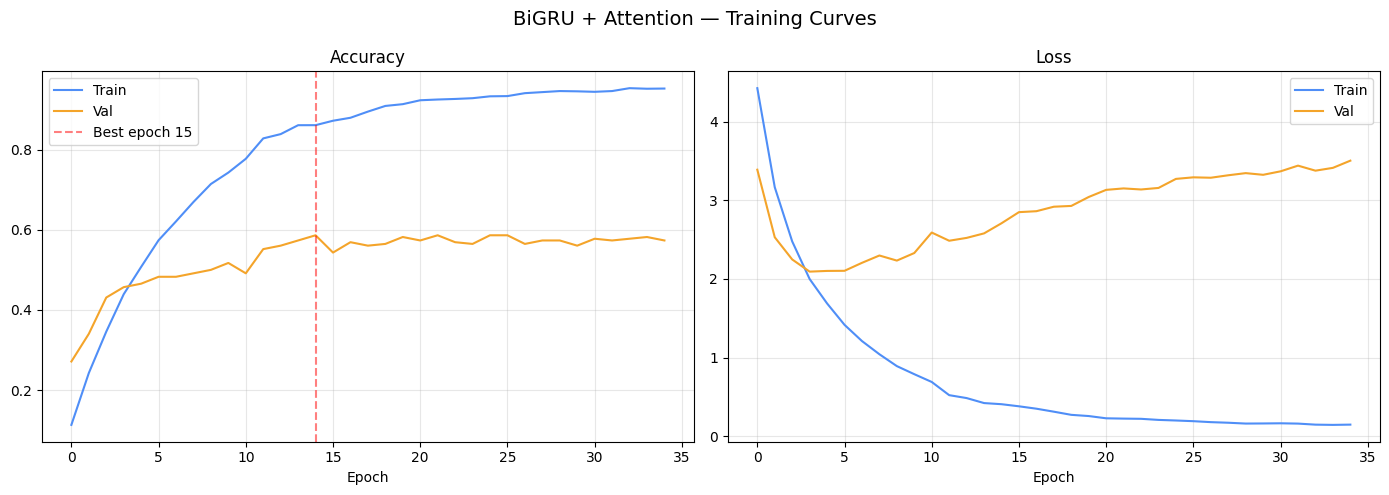

Saved: ../saved_models/v2/bigru_attn_v2_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train", color="#4f8ef7")
axes[0].plot(history.history["val_accuracy"], label="Val",   color="#f4a42a")
axes[0].axvline(best_epoch - 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch {best_epoch}")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train", color="#4f8ef7")
axes[1].plot(history.history["val_loss"], label="Val",   color="#f4a42a")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("BiGRU + Attention — Training Curves", fontsize=14)
plt.tight_layout()
curves_path = MODEL_DIR / "bigru_attn_v2_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Saved: {curves_path}")

In [8]:
import datetime

model_card = {
    "model_name"      : "bigru_attn_v2",
    "architecture"    : "BiGRU + MultiHeadAttention",
    "feature_type"    : "MediaPipe HandLandmarker (wrist-relative, palm-scale normalised)",
    "sequence_length" : SEQUENCE_LEN,
    "num_features"    : NUM_FEATURES,
    "num_classes"     : NUM_CLASSES,
    "batch_size"      : BATCH_SIZE,
    "learning_rate"   : LR,
    "best_epoch"      : best_epoch,
    "best_val_acc"    : round(best_val_acc * 100, 2),
    "test_top1"       : round(test_top1 * 100, 2),
    "test_top3"       : round(top3 * 100, 2),
    "test_top5"       : round(top5 * 100, 2),
    "training_time_min": round(elapsed / 60, 1),
    "training_date"   : datetime.datetime.now().isoformat(),
    "checkpoint"      : str(CHECKPOINT_PATH),
}

card_path = MODEL_DIR / "model_card_v2.json"
with open(card_path, "w") as f:
    json.dump(model_card, f, indent=2)
print(f"Saved: {card_path}")

Saved: ../saved_models/v2/model_card_v2.json


In [9]:
print("=" * 50)
print("FINDINGS SUMMARY")
print("=" * 50)
print(f"Best val accuracy : {best_val_acc * 100:.2f}% at epoch {best_epoch}")
print(f"Test Top-1        : {test_top1 * 100:.2f}%")
print(f"Test Top-3        : {top3 * 100:.2f}%")
print(f"Test Top-5        : {top5 * 100:.2f}%")
print(f"Training time     : {elapsed / 60:.1f} min")
print(f"Model saved       : {CHECKPOINT_PATH}")
print("=" * 50)

FINDINGS SUMMARY
Best val accuracy : 58.62% at epoch 15
Test Top-1        : 62.15%
Test Top-3        : 79.57%
Test Top-5        : 85.59%
Training time     : 8.5 min
Model saved       : ../saved_models/v2/bigru_attn_v2_best.keras
